In [1]:
import pandas as pd

# Load all three tables
customers = pd.read_csv("customers.csv")
products  = pd.read_csv("products.csv")
sales     = pd.read_csv("sales.csv")

# Basic shape check
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Sales:", sales.shape)

# Preview each table
print(customers.head())
print(products.head())
print(sales.head())

# Check column names and data types
print(customers.info())
print(products.info())
print(sales.info())

# Summary statistics
print(customers.describe())
print(products.describe())
print(sales.describe())

Customers: (40000, 15)
Products: (2000, 12)
Sales: (250000, 21)
    Customer_ID  Customer_Name  Gender  Age Age_Group Date_of_Birth  \
0  CUST00000001  Akash Agarwal    male   48     46-55    1977-01-13   
1  CUST00000002  Farhan Rahman    male   73       65+    1952-01-20   
2  CUST00000003   Suresh Kumar    male   31     26-35    1994-01-09   
3  CUST00000004  Aditya Pandey    male   41     36-45    1984-01-12   
4  CUST00000005      Hina Khan  female   53     46-55    1972-01-15   

                      Email           Phone      City        State  Pincode  \
0    akashagarwal@gmail.com  +91-9625152011   Patiala       Punjab   122521   
1    farhanrahman@gmail.com  +91-8593009465  Durgapur  West Bengal   226518   
2  sureshkumar755@gmail.com  +91-7935884774  Gurugram      Haryana   520400   
3  adityapandey@outlook.com  +91-9015046072   Kolkata  West Bengal   735356   
4     hinakhan433@gmail.com  +91-8813094271     Noida           UP   985141   

  Registration_Date Customer_Tier 

In [4]:
import pandas as pd
customers = pd.read_csv("customers.csv")
products  = pd.read_csv("products.csv")
sales     = pd.read_csv("sales.csv")

# ── 1. Fix Date Columns ───────────────────────────────────
customers['Date_of_Birth']    = pd.to_datetime(customers['Date_of_Birth'])
customers['Registration_Date'] = pd.to_datetime(customers['Registration_Date'])

sales['Order_Date']    = pd.to_datetime(sales['Order_Date'])
sales['Delivery_Date'] = pd.to_datetime(sales['Delivery_Date'])
sales['Order_Time']    = pd.to_datetime(sales['Order_Time'], format='%H:%M:%S').dt.time

# ── 2. Handle Missing Values ──────────────────────────────

# Coupon_Code: 80% missing → fill with "No Coupon" (not dropped, useful as a flag)
sales['Coupon_Code'] = sales['Coupon_Code'].fillna('No Coupon')

# Rating & Review_Text: 52% missing → only filled for Delivered orders
# For non-delivered orders, NaN is expected — keep as is
# Just flag them
sales['Has_Review'] = sales['Rating'].notna().astype(int)


# ── 3. Remove Duplicates ──────────────────────────────────
print("Duplicates in customers:", customers.duplicated().sum())
print("Duplicates in products:",  products.duplicated().sum())
print("Duplicates in sales:",     sales.duplicated().sum())

customers.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
sales.drop_duplicates(inplace=True)

Duplicates in customers: 0
Duplicates in products: 0
Duplicates in sales: 0


In [5]:
# ── 4. Remove Invalid Rows ────────────────────────────────
invalid = sales[sales['Total_Amount'] < 0]
print(f"Invalid negative Total_Amount rows: {len(invalid)}")
sales = sales[sales['Total_Amount'] >= 0]

# ── 5. Verify Cleaning ────────────────────────────────────
print("\n--- After Cleaning ---")
print("Customers shape:", customers.shape)
print("Products shape:",  products.shape)
print("Sales shape:",     sales.shape)
print("\nSales nulls:\n", sales.isnull().sum())
print("\nData types - Sales:\n", sales.dtypes)

Invalid negative Total_Amount rows: 5

--- After Cleaning ---
Customers shape: (40000, 15)
Products shape: (2000, 12)
Sales shape: (249995, 22)

Sales nulls:
 Order_ID                   0
Customer_ID                0
Product_ID                 0
Order_Date                 0
Order_Time                 0
Delivery_Date              0
Quantity                   0
Unit_Price                 0
Order_Value                0
Shipping_Cost              0
Coupon_Code                0
Coupon_Discount            0
Total_Amount               0
Payment_Mode               0
Order_Status               0
Rating                129969
Review_Text           129969
City                       0
State                      0
Customer_Age               0
Customer_Age_Group         0
Has_Review                 0
dtype: int64

Data types - Sales:
 Order_ID                      object
Customer_ID                   object
Product_ID                    object
Order_Date            datetime64[ns]
Order_Time          

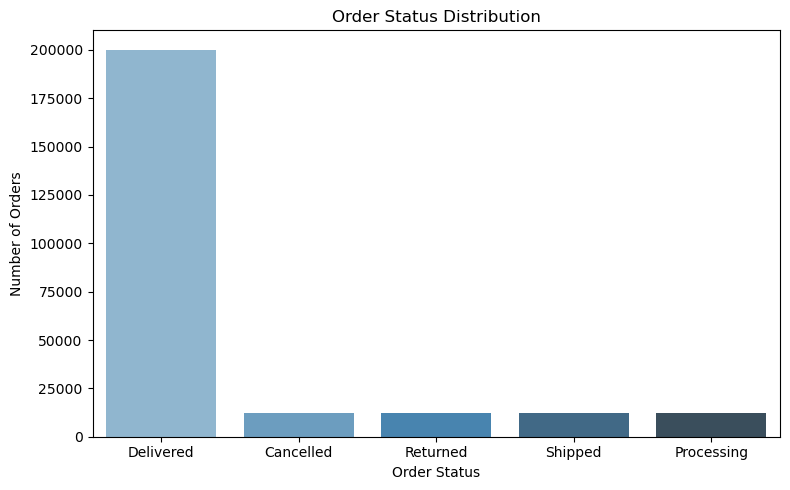

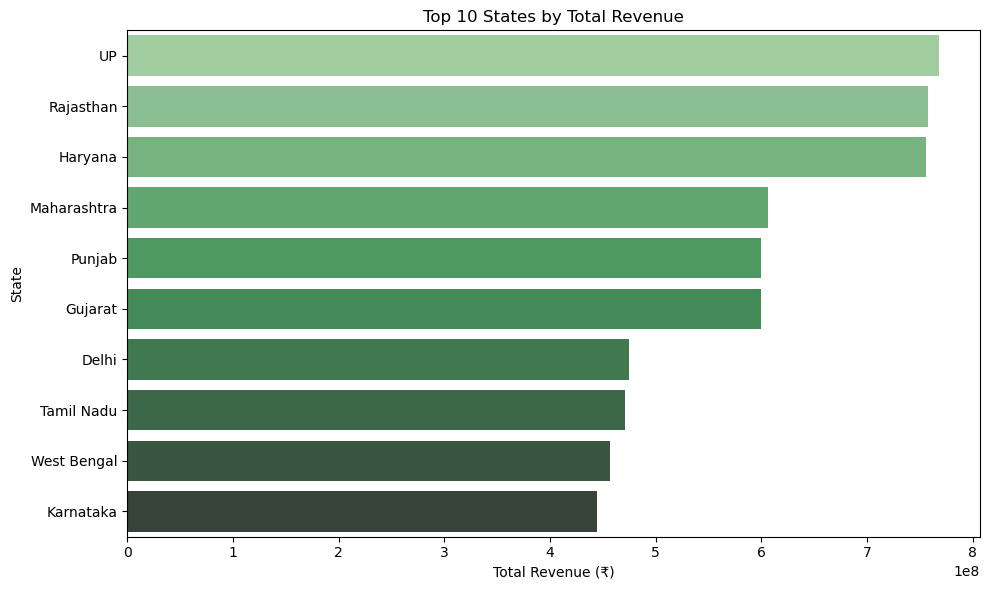

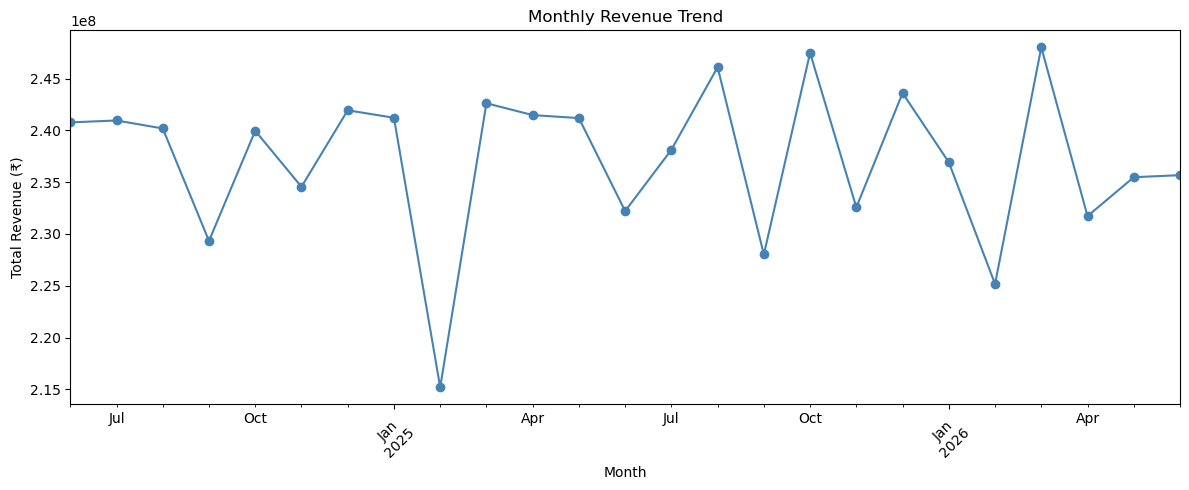

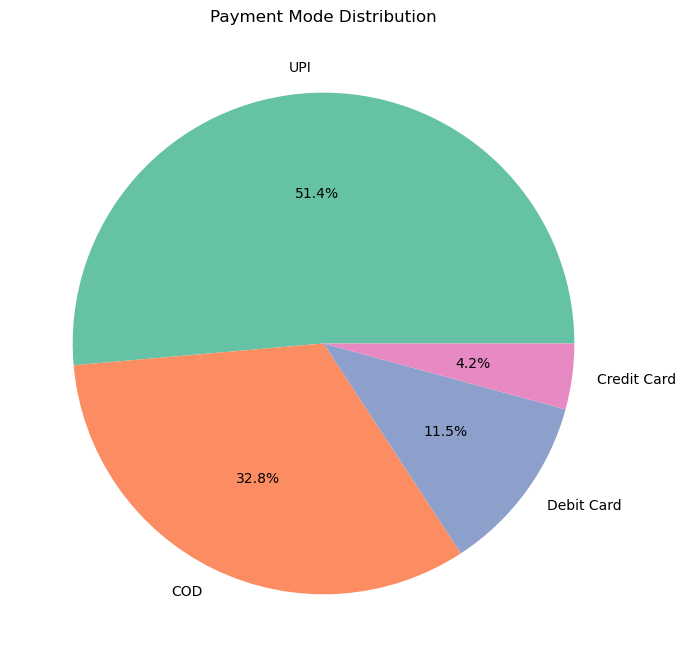

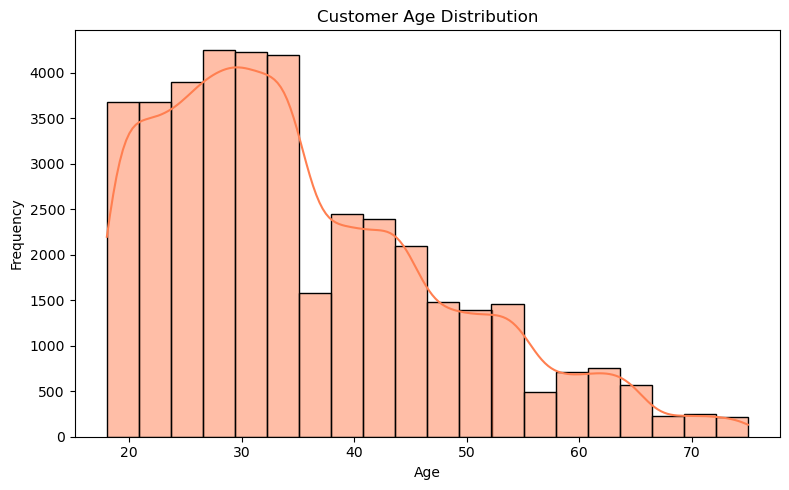

All visualizations saved!


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Visualization 1: Order Status Distribution ──
plt.figure(figsize=(8, 5))
order_counts = sales['Order_Status'].value_counts()
sns.barplot(x=order_counts.index, y=order_counts.values,
            hue=order_counts.index, palette='Blues_d', legend=False)
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('viz1_order_status.png', dpi=150)
plt.show()

# ── Visualization 2: Top 10 States by Total Revenue ──
plt.figure(figsize=(10, 6))
state_revenue = sales.groupby('State')['Total_Amount'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=state_revenue.values, y=state_revenue.index,
            hue=state_revenue.index, palette='Greens_d', legend=False)
plt.title('Top 10 States by Total Revenue')
plt.xlabel('Total Revenue (₹)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('viz2_state_revenue.png', dpi=150)
plt.show()

# ── Visualization 3: Monthly Revenue Trend ──
plt.figure(figsize=(12, 5))
sales['Month'] = sales['Order_Date'].dt.to_period('M')
monthly_revenue = sales.groupby('Month')['Total_Amount'].sum()
monthly_revenue.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('viz3_monthly_revenue.png', dpi=150)
plt.show()

# ── Visualization 4: Payment Mode Distribution ──
plt.figure(figsize=(7, 7))
payment_counts = sales['Payment_Mode'].value_counts()
plt.pie(payment_counts.values, labels=payment_counts.index,
        autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Payment Mode Distribution')
plt.tight_layout()
plt.savefig('viz4_payment_mode.png', dpi=150)
plt.show()

# ── Visualization 5: Customer Age Distribution ──
plt.figure(figsize=(8, 5))
sns.histplot(customers['Age'], bins=20, kde=True, color='coral')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('viz5_age_distribution.png', dpi=150)
plt.show()

print("All visualizations saved!")

In [9]:
# ── Quick Stats for Insights ──────────────────────────────
print("=" * 50)
print("KEY INSIGHTS SUMMARY")
print("=" * 50)

# 1. Order Status
print("\n1. ORDER STATUS:")
print(sales['Order_Status'].value_counts())

# 2. Top 5 States by Revenue
print("\n2. TOP 5 STATES BY REVENUE:")
print(sales.groupby('State')['Total_Amount'].sum().sort_values(ascending=False).head(5))

# 3. Monthly Revenue (min and max month)
monthly = sales.groupby('Month')['Total_Amount'].sum()
print("\n3. MONTHLY REVENUE:")
print(f"   Best month  : {monthly.idxmax()} → ₹{monthly.max():,.2f}")
print(f"   Worst month : {monthly.idxmin()} → ₹{monthly.min():,.2f}")

# 4. Payment Mode
print("\n4. PAYMENT MODE:")
print(sales['Payment_Mode'].value_counts())

# 5. Customer Age
print("\n5. CUSTOMER AGE:")
print(f"   Mean age : {customers['Age'].mean():.1f}")
print(f"   Most common age group: {customers['Age_Group'].value_counts().idxmax()}")

print("\n" + "=" * 50)

KEY INSIGHTS SUMMARY

1. ORDER STATUS:
Order_Status
Delivered     200135
Cancelled      12506
Returned       12493
Shipped        12459
Processing     12402
Name: count, dtype: int64

2. TOP 5 STATES BY REVENUE:
State
UP             7.683510e+08
Rajasthan      7.572865e+08
Haryana        7.552153e+08
Maharashtra    6.058307e+08
Punjab         5.992254e+08
Name: Total_Amount, dtype: float64

3. MONTHLY REVENUE:
   Best month  : 2026-03 → ₹248,032,785.65
   Worst month : 2025-02 → ₹215,193,135.50

4. PAYMENT MODE:
Payment_Mode
UPI            128471
COD             82091
Debit Card      28856
Credit Card     10577
Name: count, dtype: int64

5. CUSTOMER AGE:
   Mean age : 35.3
   Most common age group: 26-35

